# Exploratory Data Analysis

This notebook explores transaction patterns in the PaySim dataset and compares fraudulent and non-fraudulent transactions using statistical summaries and visualisations.

In [1]:
import pandas as pd

file_path = "../data/PS_20174392719_1491204439457_log.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

Dataset loaded successfully
Dataset shape: (6362620, 11)


## Transaction Type Distribution

This section examines the number and percentage of transactions for each transaction type.

In [4]:
transaction_type_counts = df["type"].value_counts()

transaction_type_percentages = (
    df["type"].value_counts(normalize=True) * 100
)

transaction_type_summary = pd.DataFrame({
    "Transaction Count": transaction_type_counts,
    "Percentage": transaction_type_percentages.round(2)
})

print(transaction_type_summary)

          Transaction Count  Percentage
type                                   
CASH_OUT            2237500       35.17
PAYMENT             2151495       33.81
CASH_IN             1399284       21.99
TRANSFER             532909        8.38
DEBIT                 41432        0.65


### Transaction Type Distribution Chart

This chart shows the total number of transactions for each transaction type.

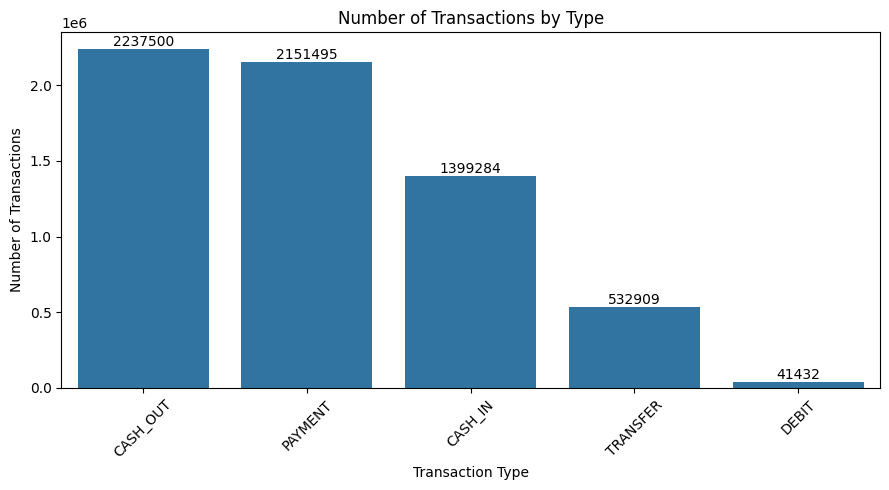

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=transaction_type_counts.index,
    y=transaction_type_counts.values
)

plt.title("Number of Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

## Fraud Analysis by Transaction Type

This section compares the total transactions, fraud transactions, and fraud rate for each transaction type.

In [13]:
fraud_by_type = (
    df.groupby("type")["isFraud"]
    .agg(["count", "sum"])
    .reset_index()
)

fraud_by_type.columns = [
    "Transaction Type",
    "Total Transactions",
    "Fraud Transactions"
]

fraud_by_type["Fraud Rate (%)"] = (
    fraud_by_type["Fraud Transactions"]
    / fraud_by_type["Total Transactions"]
    * 100
).round(4)

fraud_by_type = fraud_by_type.sort_values(
    by="Fraud Transactions",
    ascending=False
)

fraud_by_type

,Transaction Type,Total Transactions,Fraud Transactions,Fraud Rate (%)
1,CASH_OUT,2237500,4116,0.1840
4,TRANSFER,532909,4097,0.7688
0,CASH_IN,1399284,0,0.0000
2,DEBIT,41432,0,0.0000
3,PAYMENT,2151495,0,0.0000


### Fraud Transactions by Type

This chart compares the number of fraudulent transactions across transaction types that contain fraud.

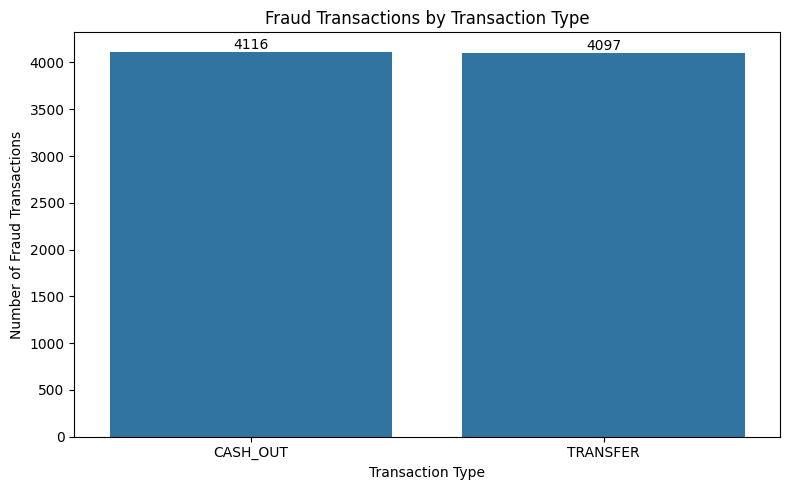

In [14]:
fraud_only = fraud_by_type[
    fraud_by_type["Fraud Transactions"] > 0
]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=fraud_only,
    x="Transaction Type",
    y="Fraud Transactions"
)

plt.title("Fraud Transactions by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Fraud Transactions")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

### Fraud Rate by Transaction Type

This chart compares the percentage of transactions identified as fraud within each transaction type that contains fraud.

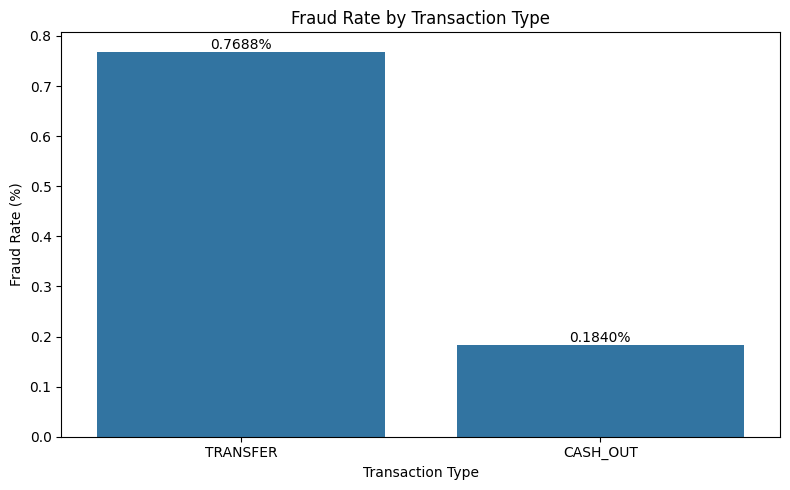

In [15]:
fraud_rate_plot = fraud_only.sort_values(
    by="Fraud Rate (%)",
    ascending=False
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=fraud_rate_plot,
    x="Transaction Type",
    y="Fraud Rate (%)"
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f%%")

plt.tight_layout()
plt.show()

### Fraud by Transaction Type — Key Insight

Fraud occurs only in `CASH_OUT` and `TRANSFER` transactions in this dataset.

`CASH_OUT` contains 4,116 fraud cases, while `TRANSFER` contains 4,097 fraud cases. Although the fraud counts are almost equal, the fraud rate is much higher for `TRANSFER`.

- `TRANSFER` fraud rate: 0.7688%
- `CASH_OUT` fraud rate: 0.1840%

This indicates that `TRANSFER` transactions have a higher relative fraud risk. Therefore, transaction type may be an important feature when building the fraud-detection model.

`CASH_IN`, `DEBIT`, and `PAYMENT` contain no labelled fraud transactions in this dataset.